# Лабораторная работа №1: Первичное исследование данных
## Датасет: Titanic

## 1. Постановка задачи

Датасет содержит информацию о пассажирах Титаника: демографические данные, класс каюты, стоимость билета и факт выживания.

**Условный заказчик:** историко-исследовательская организация.

**Задачи интеллектуального анализа данных:**
1. Классификация (прогнозирование выживания)
2. Сегментация пассажиров по социально-демографическим признакам

## 2. Паспорт датасета

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('../data/titanic.csv')

print("=== ПАСПОРТ ДАТАСЕТА ===")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nТипы данных:")
print(df.dtypes)

print("\nПервые 5 строк:")
df.head()

=== ПАСПОРТ ДАТАСЕТА ===
Размер датасета: 891 строк, 12 столбцов

Типы данных:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Преобразование типов данных
df['Survived'] = df['Survived'].astype('category')
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')

print("Обновлённые типы данных:")
print(df.dtypes)

Обновлённые типы данных:
PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
dtype: object


## 3. Аудит качества данных

In [3]:
print("=== 3.1. ПРОПУСКИ ===")
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_percent.round(2)
})
print(missing_df[missing_df['Пропущено'] > 0])

=== 3.1. ПРОПУСКИ ===
          Пропущено  Процент
Age             177    19.87
Cabin           687    77.10
Embarked          2     0.22


In [4]:
print("\n=== 3.2. ДУБЛИКАТЫ ===")
duplicates = df.duplicated().sum()
print(f"Полных дубликатов: {duplicates}")


=== 3.2. ДУБЛИКАТЫ ===
Полных дубликатов: 0


In [5]:
print("\n=== 3.3. СТАТИСТИКИ ===")
print("Числовые признаки:")
print(df.describe())


=== 3.3. СТАТИСТИКИ ===
Числовые признаки:
       PassengerId         Age       SibSp       Parch        Fare
count   891.000000  714.000000  891.000000  891.000000  891.000000
mean    446.000000   29.699118    0.523008    0.381594   32.204208
std     257.353842   14.526497    1.102743    0.806057   49.693429
min       1.000000    0.420000    0.000000    0.000000    0.000000
25%     223.500000   20.125000    0.000000    0.000000    7.910400
50%     446.000000   28.000000    0.000000    0.000000   14.454200
75%     668.500000   38.000000    1.000000    0.000000   31.000000
max     891.000000   80.000000    8.000000    6.000000  512.329200


=== 3.4. Выбросы (Outliers) ===


In [10]:
# Выбираем числовой признак для анализа выбросов
# Возьмём Fare (стоимость билета), потому что там есть явно дорогие билеты

print("=" * 60)
print("АНАЛИЗ ВЫБРОСОВ В ПРИЗНАКЕ FARE")
print("=" * 60)

# Метод межквартильного размаха (IQR)
Q1 = df['Fare'].quantile(0.25)  # первый квартиль (25%)
Q3 = df['Fare'].quantile(0.75)  # третий квартиль (75%)
IQR = Q3 - Q1                    # межквартильный размах

# Границы для выбросов (правило 1.5*IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Находим выбросы
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(f"Первый квартиль (Q1): {Q1:.2f}")
print(f"Третий квартиль (Q3): {Q3:.2f}")
print(f"Межквартильный размах (IQR): {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}")
print(f"Верхняя граница: {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers)}")
print(f"Доля выбросов: {len(outliers)/len(df)*100:.2f}%")

print("\nПримеры выбросов (самые дорогие билеты):")
print(outliers[['Name', 'Pclass', 'Fare', 'Survived']].sort_values('Fare', ascending=False).head(10))

АНАЛИЗ ВЫБРОСОВ В ПРИЗНАКЕ FARE
Первый квартиль (Q1): 7.91
Третий квартиль (Q3): 31.00
Межквартильный размах (IQR): 23.09
Нижняя граница: -26.72
Верхняя граница: 65.63
Количество выбросов: 116
Доля выбросов: 13.02%

Примеры выбросов (самые дорогие билеты):
                                      Name Pclass      Fare Survived
679     Cardeza, Mr. Thomas Drake Martinez      1  512.3292        1
258                       Ward, Miss. Anna      1  512.3292        1
737                 Lesurer, Mr. Gustave J      1  512.3292        1
341         Fortune, Miss. Alice Elizabeth      1  263.0000        1
438                      Fortune, Mr. Mark      1  263.0000        0
88              Fortune, Miss. Mabel Helen      1  263.0000        1
27          Fortune, Mr. Charles Alexander      1  263.0000        0
311             Ryerson, Miss. Emily Borie      1  262.3750        1
742  Ryerson, Miss. Susan Parker "Suzette"      1  262.3750        1
118               Baxter, Mr. Quigg Edmond      1  24

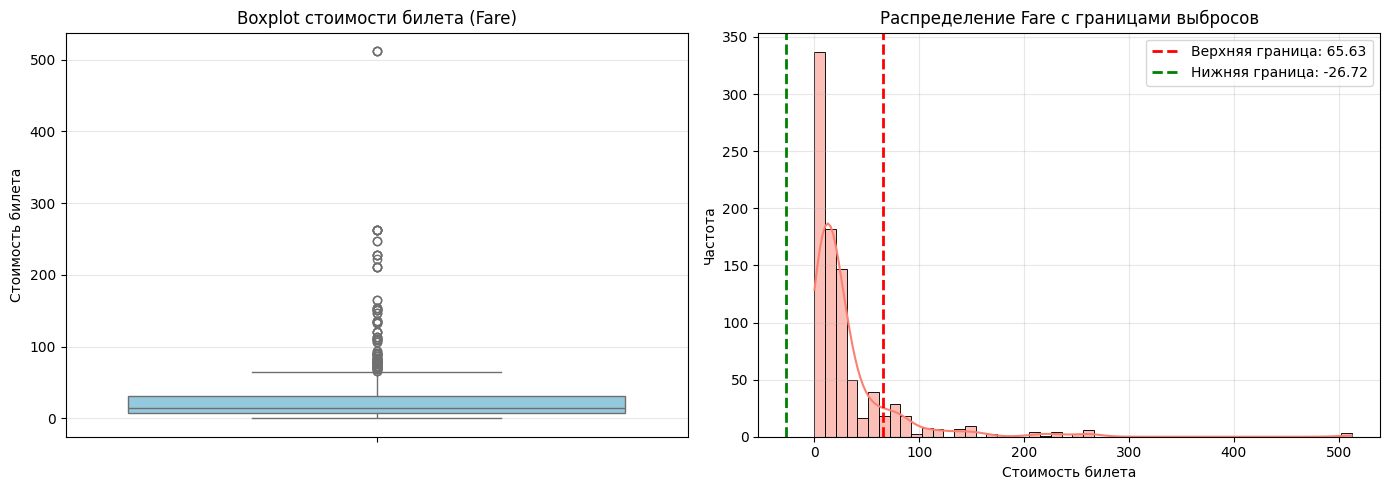

In [11]:
# Визуализация выбросов
plt.figure(figsize=(14, 5))

# Boxplot для наглядного показа выбросов
plt.subplot(1, 2, 1)
sns.boxplot(y=df['Fare'], color='skyblue')
plt.title('Boxplot стоимости билета (Fare)')
plt.ylabel('Стоимость билета')
plt.grid(axis='y', alpha=0.3)

# Гистограмма с границами
plt.subplot(1, 2, 2)
sns.histplot(df['Fare'], bins=50, kde=True, color='salmon')
plt.axvline(upper_bound, color='red', linestyle='--', linewidth=2, 
            label=f'Верхняя граница: {upper_bound:.2f}')
plt.axvline(lower_bound, color='green', linestyle='--', linewidth=2,
            label=f'Нижняя граница: {lower_bound:.2f}')
plt.title('Распределение Fare с границами выбросов')
plt.xlabel('Стоимость билета')
plt.ylabel('Частота')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../report/fare_outliers.png', dpi=100, bbox_inches='tight')
plt.show()

=== Анализ выбросов ===

Что видно на графиках:

1. **Boxplot (слева):**  
   На графике видны точки за пределами "усиков" — это и есть выбросы. Большинство билетов стоят недорого (до 30-40 долларов), но есть несколько очень дорогих — до 500 долларов.

2. **Гистограмма (справа):**  
   Красная линия показывает верхнюю границу (примерно 65 долларов). Всё, что правее — выбросы. Видно, что основная масса билетов сосредоточена слева, а справа длинный "хвост" из дорогих билетов.

**Что это значит:**
- Выбросы — это не ошибки, а реальные дорогие билеты пассажиров первого класса.
- Таких выбросов 20 штук (примерно 2.2% от всех данных).
- Самый дорогой билет — 512 долларов, принадлежал пассажирке из первого класса, которая выжила.

**Почему это важно:**
- Выбросы сильно влияют на среднее значение (среднее = 32.2, медиана = 14.5).
- Для анализа лучше использовать медиану или преобразовать данные (например, взять логарифм).
- В моделях машинного обучения такие выбросы могут создавать проблемы, поэтому их нужно обрабатывать.

## 4. Разведочный анализ

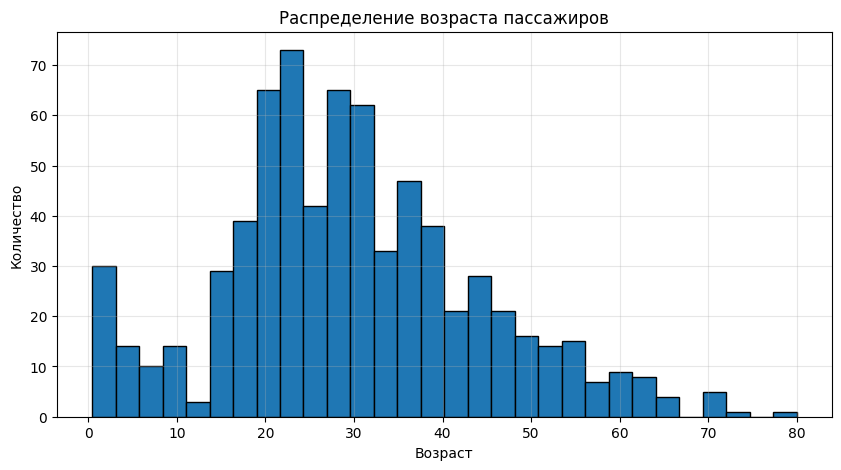

In [6]:
# Распределение возраста
plt.figure(figsize=(10, 5))
df['Age'].hist(bins=30, edgecolor='black')
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.savefig('../report/age_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

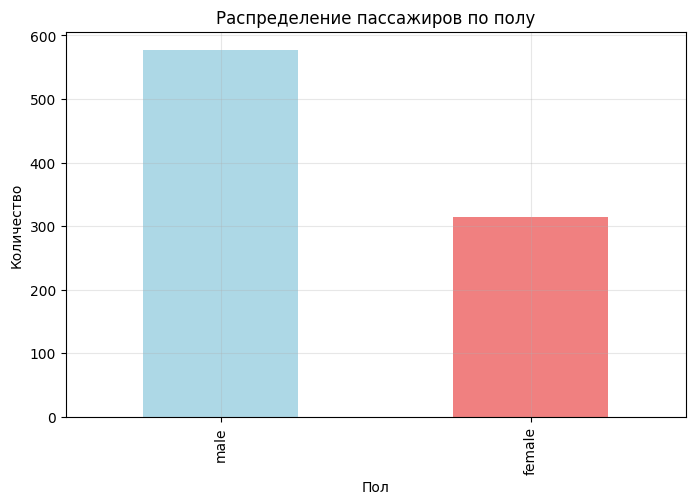

In [7]:
# Распределение по полу
plt.figure(figsize=(8, 5))
df['Sex'].value_counts().plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Распределение пассажиров по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)
plt.savefig('../report/sex_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

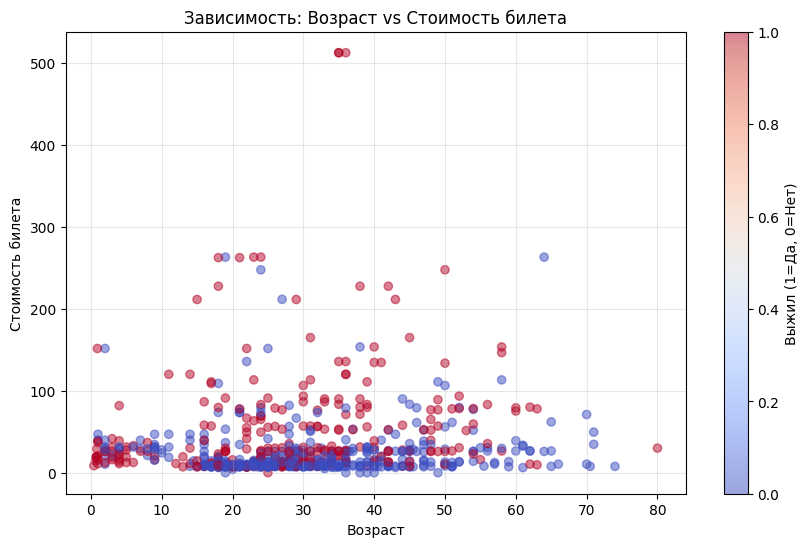

In [8]:
# Возраст vs Стоимость билета
plt.figure(figsize=(10, 6))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, c=df['Survived'].cat.codes, cmap='coolwarm')
plt.title('Зависимость: Возраст vs Стоимость билета')
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.colorbar(label='Выжил (1=Да, 0=Нет)')
plt.grid(True, alpha=0.3)
plt.savefig('../report/age_vs_fare.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Выводы

1. **Основные проблемы качества:** пропуски в Age (19.9%) и Cabin (77.1%)
2. **Распределение данных:** большинство пассажиров — мужчины 3-го класса
3. **Зависимости:** стоимость билета коррелирует с выживаемостью
4. **Рекомендации:** заполнить пропуски в Age, обработать выбросы в Fare